In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv("Student_Performance.csv")
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [3]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## Get random sample of 1000 students out of population

In [7]:
df1 = df.sample(n=1000)

## Graph each variable

Text(0, 0.5, 'Count')

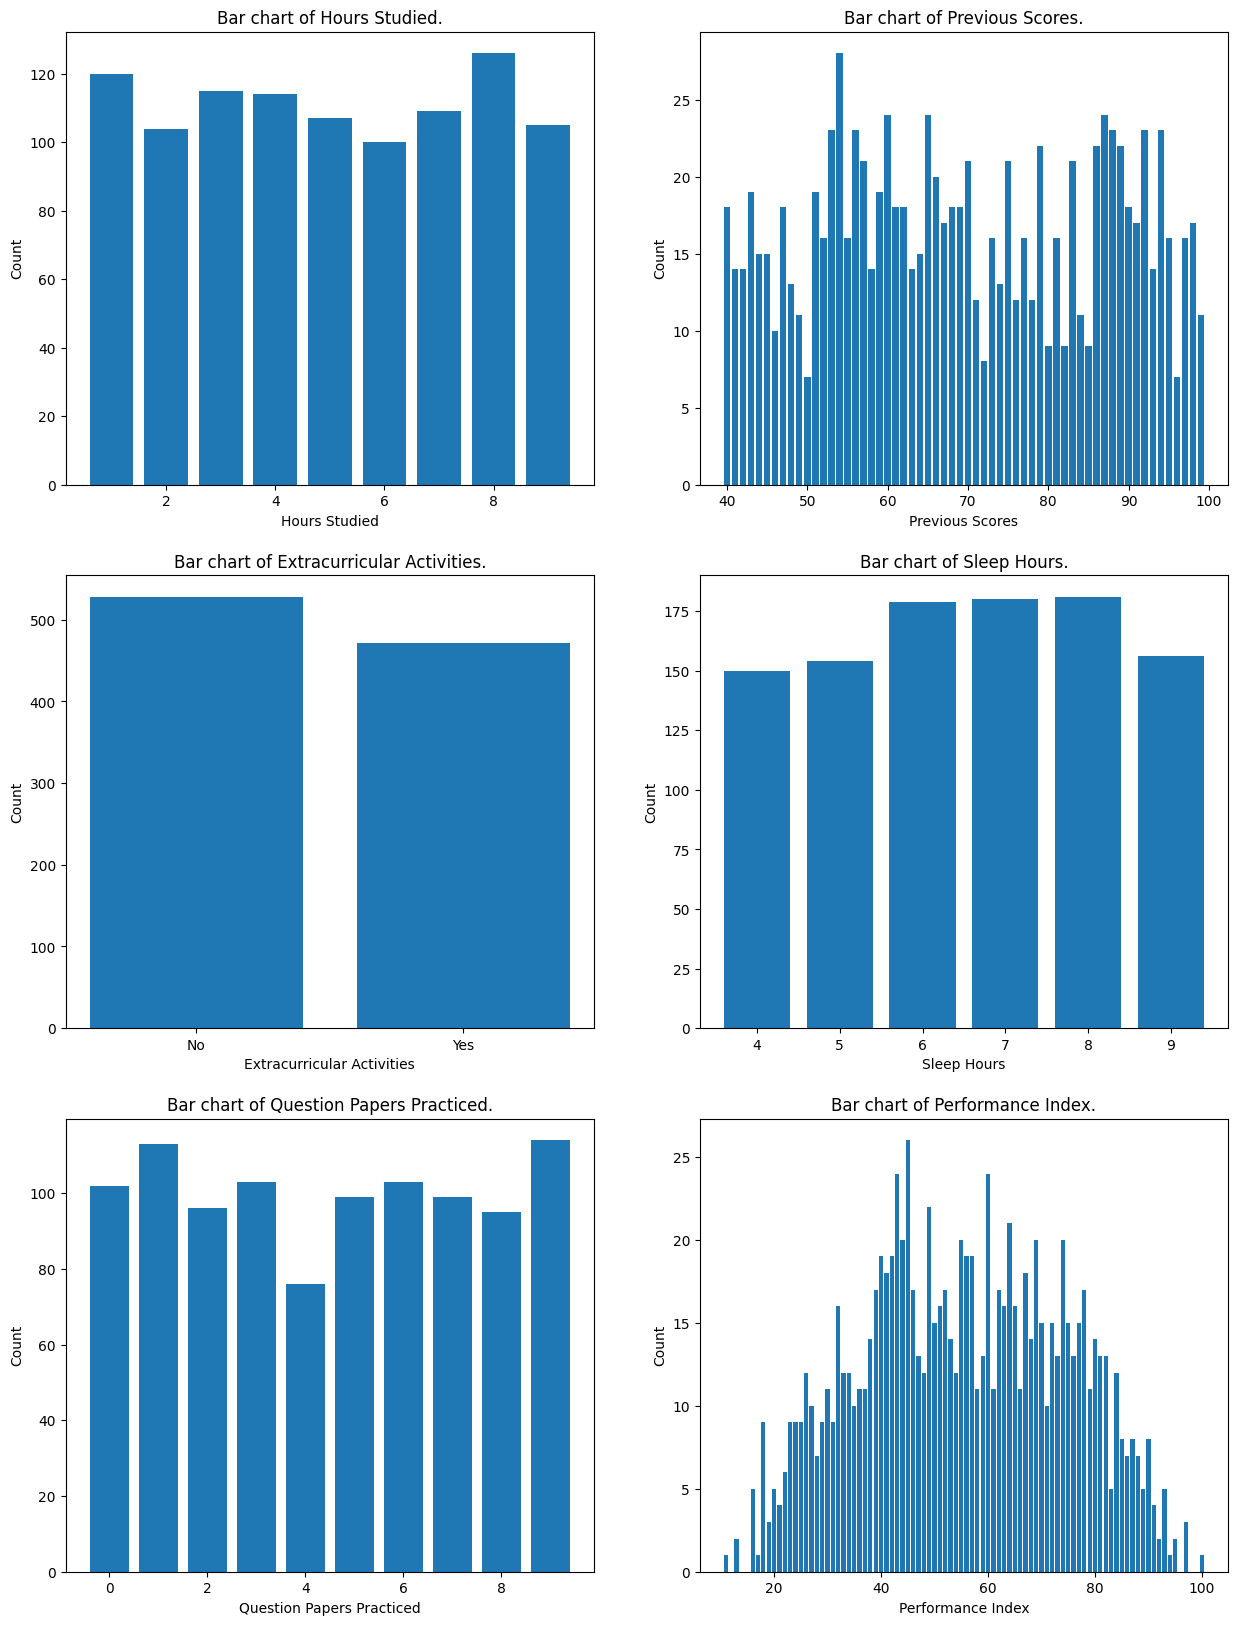

In [24]:
# The total number of hours spent studying by each student
hours_studied = df1["Hours Studied"].value_counts()

# The scores obtained by students in previous tests
previous_scores = df1['Previous Scores'].value_counts()

# Whether the student participates in extracurricular activities (Yes or No)
extra_activity = df1['Extracurricular Activities'].value_counts()

# The average number of hours of sleep the student had per day.
sleep_hours = df1['Sleep Hours'].value_counts()

# The number of sample question papers the student practiced
practiced = df1['Sample Question Papers Practiced'].value_counts()

# The academic performance of each student
performance = df1['Performance Index'].value_counts()

# Vẽ biểu đồ bar chart với Matplotlib
plt.figure(figsize=(15,20))
plt.subplot(3, 2, 1)
plt.bar(hours_studied.index, hours_studied.values)
plt.title('Bar chart of Hours Studied.')
plt.xlabel('Hours Studied')
plt.ylabel('Count')

plt.subplot(3, 2, 2)
plt.bar(previous_scores.index, previous_scores.values)
plt.title('Bar chart of Previous Scores.')
plt.xlabel('Previous Scores')
plt.ylabel('Count')

plt.subplot(3, 2, 3)
plt.bar(extra_activity.index, extra_activity.values)
plt.title('Bar chart of Extracurricular Activities.')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Count')

plt.subplot(3, 2, 4)
plt.bar(sleep_hours.index, sleep_hours.values)
plt.title('Bar chart of Sleep Hours.')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')

plt.subplot(3, 2, 5)
plt.bar(practiced.index, practiced.values)
plt.title('Bar chart of Question Papers Practiced.')
plt.xlabel('Question Papers Practiced')
plt.ylabel('Count')

plt.subplot(3, 2, 6)
plt.bar(performance.index, performance.values)
plt.title('Bar chart of Performance Index.')
plt.xlabel('Performance Index')
plt.ylabel('Count')

## Calculate the statistics of each variable

In [64]:
df1.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,extra_activity_encoded
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.980000,69.479000,6.556000,4.510000,55.208000,0.472000
std,2.605069,17.051637,1.660006,2.942203,19.110624,0.499465
min,1.000000,40.000000,4.000000,0.000000,11.000000,0.000000
25%,3.000000,55.000000,5.000000,2.000000,41.000000,0.000000
50%,5.000000,68.000000,7.000000,5.000000,55.000000,0.000000
75%,7.000000,86.000000,8.000000,7.000000,70.000000,1.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000,1.000000


In [ ]:
# Hours Studied
print("Counts:\n", hours_studied)

proportion = df1['Hours Studied'].value_counts(normalize=True)
print("Proportions:\n", proportion)

n = len(df1)
std_dev = np.sqrt(proportion * (1 - proportion) / n)
print("\nStandard Deviation:\n", std_dev)

Counts:
 Hours Studied
8    126
1    120
3    115
4    114
7    109
5    107
9    105
2    104
6    100
Name: count, dtype: int64
Proportions:
 Hours Studied
8    0.126
1    0.120
3    0.115
4    0.114
7    0.109
5    0.107
9    0.105
2    0.104
6    0.100
Name: proportion, dtype: float64

Standard Deviation:
 Hours Studied
8    0.010494
1    0.010276
3    0.010088
4    0.010050
7    0.009855
5    0.009775
9    0.009694
2    0.009653
6    0.009487
Name: proportion, dtype: float64


In [ ]:
# Previous Scores
print("Counts:\n", previous_scores)

proportion = df1['Previous Scores'].value_counts(normalize=True)
print("Proportions:\n", proportion)

n = len(df1)
std_dev = np.sqrt(proportion * (1 - proportion) / n)
print("\nStandard Deviation:\n", std_dev)

Counts:
 Previous Scores
54    28
65    24
60    24
87    24
56    23
92    23
53    23
94    23
88    23
86    22
89    22
79    22
75    21
83    21
57    21
70    21
66    20
43    19
51    19
59    19
61    18
40    18
68    18
47    18
69    18
90    18
62    18
98    17
91    17
67    17
95    16
77    16
52    16
81    16
73    16
97    16
55    16
45    15
44    15
64    15
93    14
63    14
58    14
42    14
41    14
74    13
48    13
71    12
78    12
76    12
84    11
49    11
99    11
46    10
85     9
82     9
80     9
72     8
50     7
96     7
Name: count, dtype: int64
Proportions:
 Previous Scores
54    0.028
65    0.024
60    0.024
87    0.024
56    0.023
92    0.023
53    0.023
94    0.023
88    0.023
86    0.022
89    0.022
79    0.022
75    0.021
83    0.021
57    0.021
70    0.021
66    0.020
43    0.019
51    0.019
59    0.019
61    0.018
40    0.018
68    0.018
47    0.018
69    0.018
90    0.018
62    0.018
98    0.017
91    0.017
67    0.017
95    0.016
77    0

In [ ]:
# Extracurricular Activities
print("Counts:\n", extra_activity)

proportion = df1['Extracurricular Activities'].value_counts(normalize=True)
print("Proportions:\n", proportion)

n = len(df1)
std_dev = np.sqrt(proportion * (1 - proportion) / n)
print("\nStandard Deviation:\n", std_dev)

Counts:
 Extracurricular Activities
No     528
Yes    472
Name: count, dtype: int64
Proportions:
 Extracurricular Activities
No     0.528
Yes    0.472
Name: proportion, dtype: float64

Standard Deviation:
 Extracurricular Activities
No     0.015787
Yes    0.015787
Name: proportion, dtype: float64


In [ ]:
# Sleep Hours
print("Counts:\n", sleep_hours)

proportion = df1['Sleep Hours'].value_counts(normalize=True)
print("Proportions:\n", proportion)

n = len(df1)
std_dev = np.sqrt(proportion * (1 - proportion) / n)
print("\nStandard Deviation:\n", std_dev)

Counts:
 Sleep Hours
8    181
7    180
6    179
9    156
5    154
4    150
Name: count, dtype: int64
Proportions:
 Sleep Hours
8    0.181
7    0.180
6    0.179
9    0.156
5    0.154
4    0.150
Name: proportion, dtype: float64

Standard Deviation:
 Sleep Hours
8    0.012175
7    0.012149
6    0.012123
9    0.011474
5    0.011414
4    0.011292
Name: proportion, dtype: float64


In [ ]:
# Question Papers Practiced
print("Counts:\n", practiced)

proportion = df1['Sample Question Papers Practiced'].value_counts(normalize=True)
print("Proportions:\n", proportion)

n = len(df1)
std_dev = np.sqrt(proportion * (1 - proportion) / n)
print("\nStandard Deviation:\n", std_dev)

Counts:
 Sample Question Papers Practiced
9    114
1    113
6    103
3    103
0    102
7     99
5     99
2     96
8     95
4     76
Name: count, dtype: int64
Proportions:
 Sample Question Papers Practiced
9    0.114
1    0.113
6    0.103
3    0.103
0    0.102
7    0.099
5    0.099
2    0.096
8    0.095
4    0.076
Name: proportion, dtype: float64

Standard Deviation:
 Sample Question Papers Practiced
9    0.010050
1    0.010012
6    0.009612
3    0.009612
0    0.009571
7    0.009445
5    0.009445
2    0.009316
8    0.009272
4    0.008380
Name: proportion, dtype: float64


In [ ]:
# Question Papers Practiced
print("Counts:\n", practiced)

proportion = df1['Sample Question Papers Practiced'].value_counts(normalize=True)
print("Proportions:\n", proportion)

n = len(df1)
std_dev = np.sqrt(proportion * (1 - proportion) / n)
print("\nStandard Deviation:\n", std_dev)

## Hypothesis and testing

In [ ]:
# Create two groups based on Sleep Hours
sleep_less = df1[df1['Sleep Hours'] < 6]['Performance Index']
sleep_more = df1[df1['Sleep Hours'] >= 6]['Performance Index']
print("Sleep less than 6 hours")
print(sleep_less.describe())
print("\nSleep equal or more than 6 hours")
print(sleep_more.describe(), "\n")

# Hypothesis Testing: Independent two-sample t-test
# Null hypothesis: The mean performance index of the two groups is equal
# Alternative hypothesis: The mean performance index of the two groups is not equal
result = stats.ttest_ind(sleep_less, sleep_more, equal_var=False)

# Show results
print("T-statistic:", result.statistic)
print("P-value:", result.pvalue)

# Compare p-value with significance level (alpha)
alpha = 0.05
if result.pvalue < alpha:
    print("Reject null hypothesis. There is a significant difference in mean Performance Index between the two groups.")
else:
    print("Fail to reject null hypothesis. There is no significant difference in mean Performance Index between the two groups.")

Sleep less than 6 hours
count    304.000000
mean      54.628289
std       19.588590
min       11.000000
25%       39.000000
50%       56.000000
75%       71.000000
max       97.000000
Name: Performance Index, dtype: float64

Sleep equal or more than 6 hours
count    696.000000
mean      55.461207
std       18.906774
min       13.000000
25%       42.000000
50%       55.000000
75%       70.000000
max      100.000000
Name: Performance Index, dtype: float64 

T-statistic: -0.6250333583105521
P-value: 0.5322040443531724
Fail to reject null hypothesis. There is no significant difference in mean Performance Index between the two groups.


In [ ]:
# Create two groups based on whether students participate in extracurricular activities
has_extra_act = df1[df1['Extracurricular Activities'] == 'Yes']['Performance Index']
no_extra_act = df1[df1['Extracurricular Activities'] == 'No']['Performance Index']
print("Participates in extracurricular activities")
print(has_extra_act.describe())
print("\nDoesn't participate in extracurricular activities")
print(no_extra_act.describe(), '\n')

# Hypothesis Testing: Independent two-sample t-test
# Null hypothesis: The mean performance index of students who participate in extracurricular activities is equal to the mean performance index of students who don't participate in extracurricular activities
# Alternative hypothesis: The mean performance index of students who participate in extracurricular activities is less than the mean performance index of students who don't participate in extracurricular activities
result = stats.ttest_ind(has_extra_act, no_extra_act, equal_var=False, alternative='less')

# Show results
print("T-statistic:", result.statistic)
print("P-value:", result.pvalue)

# Compare p-value with significance level (alpha)
alpha = 0.05
if result.pvalue < alpha:
    print("Reject null hypothesis. There is evidence to suggest that the mean Performance Index of students who participate in extracurricular activities is less than those don't participates in extracurricular activities.")
else:
    print("Fail to reject null hypothesis. There is not enough evidence to suggest that the mean Performance Index students who participate in extracurricular activities is less than those don't participates in extracurricular activities.")

Participates in extracurricular activities
count    472.000000
mean      54.281780
std       19.091106
min       11.000000
25%       40.000000
50%       53.000000
75%       69.250000
max      100.000000
Name: Performance Index, dtype: float64

Doesn't participate in extracurricular activities
count    528.000000
mean      56.035985
std       19.108117
min       13.000000
25%       42.000000
50%       56.000000
75%       70.250000
max       97.000000
Name: Performance Index, dtype: float64 

T-statistic: -1.4499552672612916
P-value: 0.07369453536587199
Fail to reject null hypothesis. There is not enough evidence to suggest that the mean Performance Index students who participate in extracurricular activities is less than those don't participates in extracurricular activities.


## Correlation

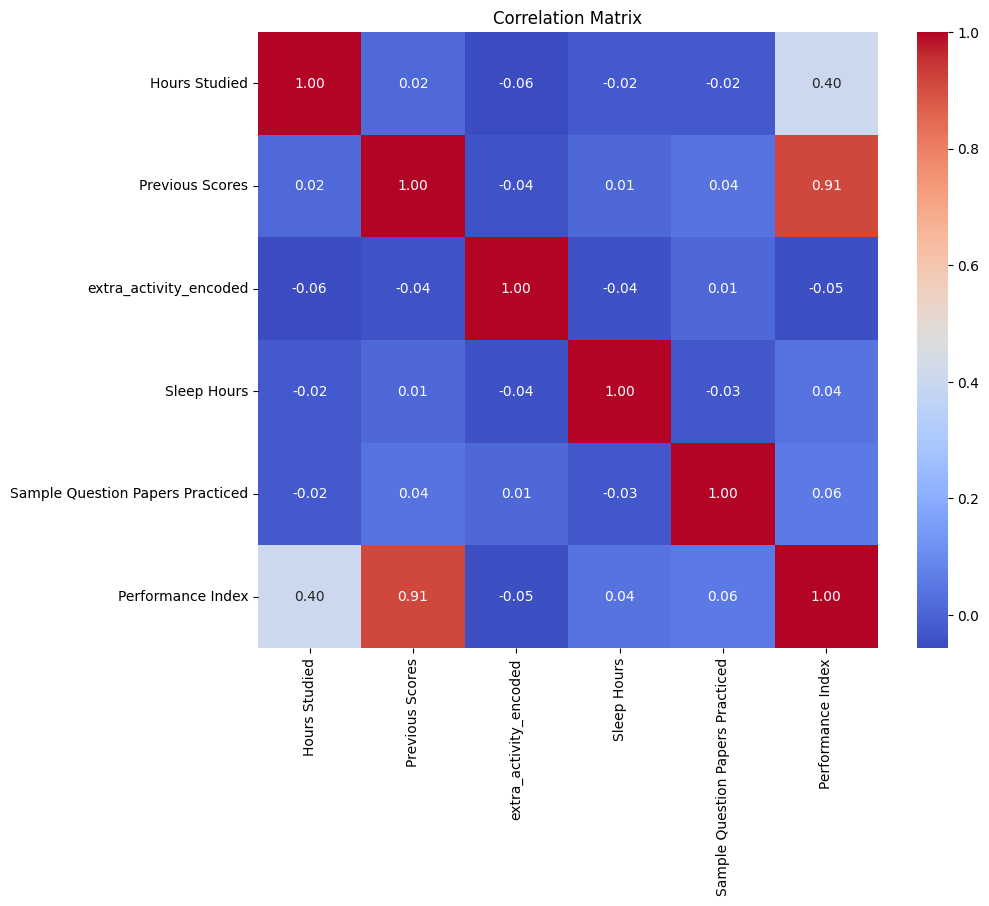

In [43]:
label_encoder = LabelEncoder()
df1['extra_activity_encoded'] = label_encoder.fit_transform(df1['Extracurricular Activities'])
correlation_matrix = df1[['Hours Studied','Previous Scores','extra_activity_encoded','Sleep Hours',
                          'Sample Question Papers Practiced','Performance Index']].corr()
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Regression

In [ ]:
x = df1['Previous Scores'].to_numpy().reshape(-1, 1)
y = df1['Performance Index'].to_numpy().reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,shuffle=True)
linear_regression = LinearRegression()
linear_regression.fit(x_train,y_train)
predictions = linear_regression.predict(x_test)

# the coefficient of determination R^2 of the prediction
linear_regression.score(x,y)

0.8358737942213993

Text(0, 0.5, 'Performance Index')

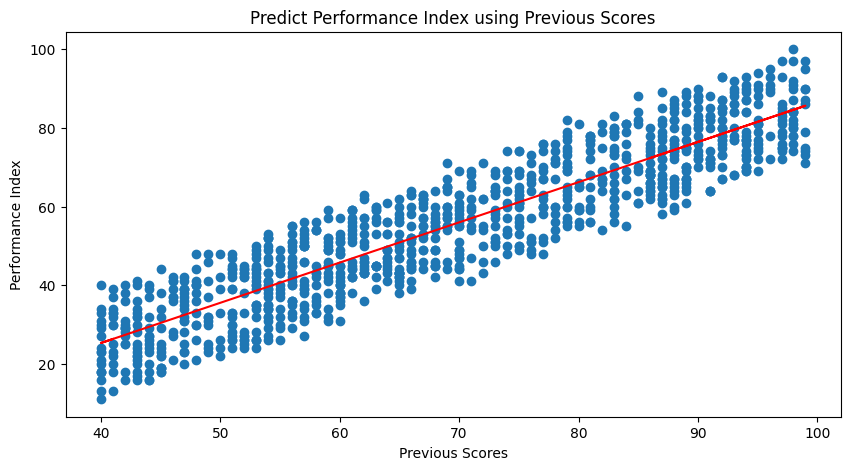

In [95]:
plt.figure(figsize=(10,5))
plt.scatter(df1['Previous Scores'], df1['Performance Index'])
plt.plot(x_test, predictions, color='red')
plt.title('Predict Performance Index using Previous Scores')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')

Text(0.5, 1.0, 'Residual Plot')

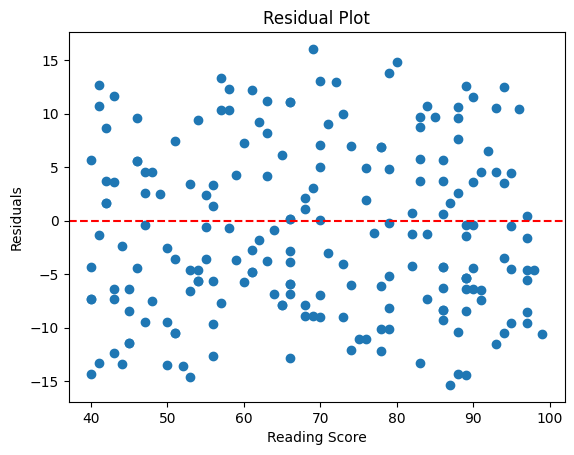

In [88]:
residuals = y_test - predictions

plt.scatter(x_test, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Reading Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')